# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


In [4]:
df.to_pickle('online_retail.pkl')
#df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [5]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 3. Calidad de datos

In [8]:
# 1. Análisis de Valores Nulos
print("\n1. VALORES NULOS POR COLUMNA:")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

# Creamos un DataFrame resumen solo con las columnas que tienen nulos
resumen_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos, 
    'Porcentaje (%)': porcentaje_nulos.round(2)
})
print(resumen_nulos[resumen_nulos['Cantidad de Nulos'] > 0])


1. VALORES NULOS POR COLUMNA:
             Cantidad de Nulos  Porcentaje (%)
Description               4382            0.41
Customer ID             243007           22.77


In [9]:
# 2. Análisis de Duplicados
print("\n2. VALORES DUPLICADOS:")
duplicados = df.duplicated().sum()
porcentaje_duplicados = (duplicados / len(df)) * 100

print(f"Filas exactamente idénticas: {duplicados}")
print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")


2. VALORES DUPLICADOS:
Filas exactamente idénticas: 34335
Porcentaje de duplicados: 3.22%


In [ ]:
# 3. Tratamiento de Duplicados
# Lo más seguro es eliminarlos.
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"\nAcción: Se han eliminado {duplicados} filas duplicadas.")
    print(f"Nuestro dataset se queda con {len(df)} filas para el modelo.")


Acción: Se han eliminado 34335 filas duplicadas.
El dataset se queda con 1033036 filas para el modelo.


In [19]:
# ---------------------------------------------------------
# LIMPIEZA DE DATOS
# ---------------------------------------------------------

print("LIMPIANDO DATASET...")

# Eliminamos las filas que corresponden a devoluciones (Invoice que empiezan con 'C')
df_clean = df[~df['Invoice'].astype(str).str.startswith('C')]

# Nos quedamos solo con las filas que tienen Customer ID (clientes identificados)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Calculamos la facturación por fila (Revenue = Quantity * Price)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Original rows: {len(df)}")
print(f"Clean rows ready for analysis: {len(df_clean)}")

LIMPIANDO DATASET...
Original rows: 1033036
Clean rows ready for analysis: 1007913


## 4. Estadísticas descriptivas
df.describe()

In [20]:
print("--- ESTADÍSTICA DESCRIPTIVA ---")

# Generamos estadísticas descriptiva para las variables numéricas
print("\n1. RESUMEN DE VARIABLES NUMÉRICAS:")
# Vamos a crear la variable Revenue para tener una métrica de ventas
numerical_summary = df_clean[['Quantity', 'Price', 'Revenue']].describe().round(2)
display(numerical_summary)

# Generamos resumen para las columnas categóricas para observar valores únicos y ocurrencias más comunes
print("\n2. RESUMEN DE VARIABLES CATEGÓRICAS:")
categorical_summary = df_clean[['Invoice', 'StockCode', 'Description', 'Country']].astype(str).describe()
display(categorical_summary)

# Calculamos métricas de forma de distribución para las variables numéricas
print("\n3. MÉTRICAS DE FORMA DE DISTRIBUCIÓN:")

# Medidas de asimetría (skewness) para entender la simetría de la distribución
print("Asimetría (Skewness):")
display(df_clean[['Quantity', 'Price', 'Revenue']].skew().round(2))

# Medidas de curtosis (kurtosis) para entender las colas de la distribución
print("\nCurtosis (Kurtosis):")
display(df_clean[['Quantity', 'Price', 'Revenue']].kurtosis().round(2))

--- ESTADÍSTICA DESCRIPTIVA ---

1. RESUMEN DE VARIABLES NUMÉRICAS:


,Quantity,Price,Revenue
count,1007913.00,1007913.00,1007913.00
mean,11.12,4.07,20.32
std,128.47,50.43,205.72
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.08
75%,12.00,4.13,17.70
max,80995.00,25111.09,168469.60



2. RESUMEN DE VARIABLES CATEGÓRICAS:


,Invoice,StockCode,Description,Country
count,1007913,1007913,1007913,1007913
unique,40077,4917,5399,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,5511,5601,926038



3. MÉTRICAS DE FORMA DE DISTRIBUCIÓN:
Asimetría (Skewness):


Quantity    453.99
Price       234.73
Revenue     608.61
dtype: float64


Curtosis (Kurtosis):


Quantity    268348.06
Price        82653.85
Revenue     467313.52
dtype: float64

## 5. Visualizaciones

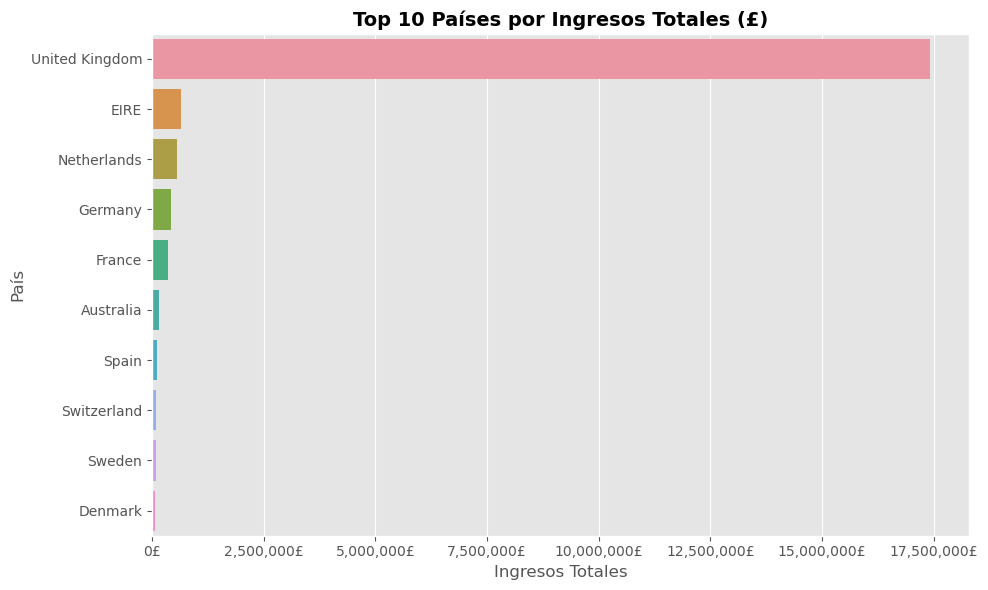

In [21]:
# ---------------------------------------------------------
# GRÁFICA 1: TOP 10 PAÍSES POR VOLUMEN DE INGRESOS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Group by country, sum revenue, sort descending and get top 10
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

# Create barplot (it will inherit the 'husl' palette automatically)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Países por Ingresos Totales (£)', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos Totales', fontsize=12)
plt.ylabel('País', fontsize=12)

# Add currency format to X axis for better readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}£".format(int(x))))
plt.tight_layout()
plt.show()

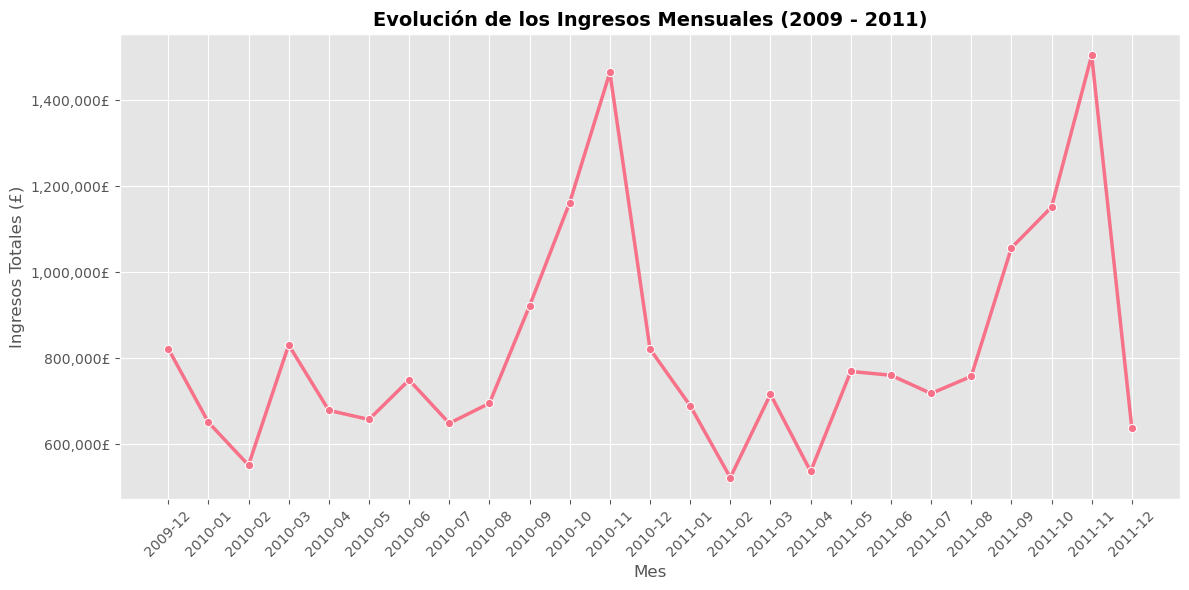

In [22]:
# ---------------------------------------------------------
# GRÁFICO 2: INGRESOS MENSUALES (EVOLUCIÓN TEMPORAL)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Creamos una nueva columna 'YearMonth' para agrupar por mes y año
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()

# Convertimos el índice a string para que se muestre como 'YYYY-MM' en el gráfico
monthly_revenue.index = monthly_revenue.index.astype(str)

# Línea de tiempo para la serie temporal (heredará el estilo 'ggplot')
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', linewidth=2.5)
plt.title('Evolución de los Ingresos Mensuales (2009 - 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales (£)', fontsize=12)
plt.xticks(rotation=45) 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}£".format(int(y))))
plt.tight_layout()
plt.show()

# Eliminamos la columna temporal 'YearMonth' que solo se usó para el gráfico
df_clean = df_clean.drop('YearMonth', axis=1)

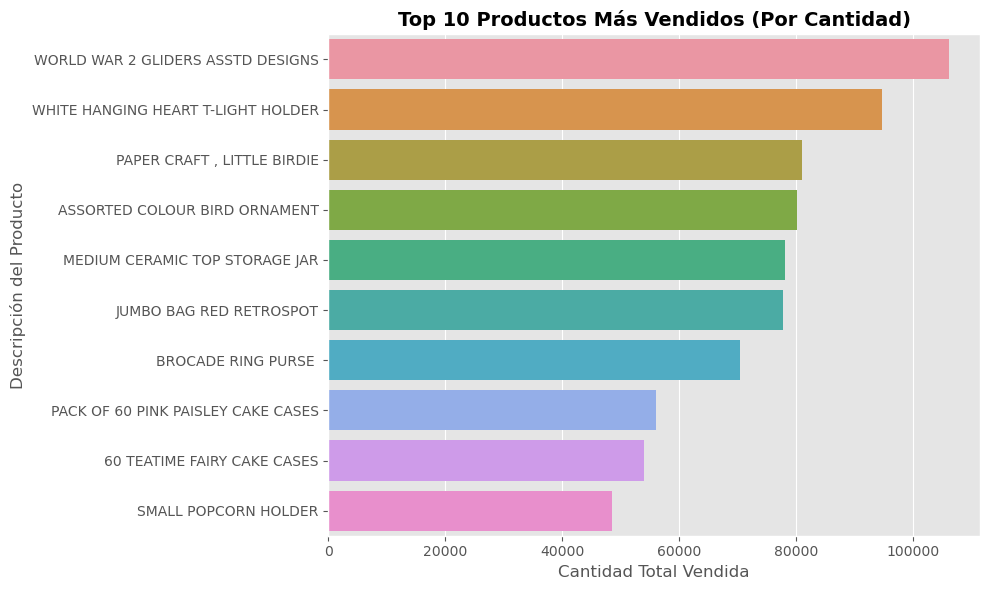

In [23]:
# ---------------------------------------------------------
# GRÁFICO 3: TOP 10 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Agrupamos por descripción del producto, sumamos la cantidad, ordenamos y obtenemos el top 10
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Creamos un barplot para los productos más vendidos (heredará la paleta 'husl')
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Productos Más Vendidos (Por Cantidad)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Total Vendida', fontsize=12)
plt.ylabel('Descripción del Producto', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [24]:
# ---------------------------------------------------------
# 6. AGREGACIÓN A NIVEL CLIENTE PARA PERFILADO DE COMPORTAMIENTO
# ---------------------------------------------------------

# Agrupamos el dataset por Customer ID para calcular métricas de comportamiento
customer_aggregation = df_clean.groupby('Customer ID').agg({
    'Revenue': 'sum',          # Totales de facturación por cliente (suma de tickets)
    'Invoice': 'nunique'       # Número de compras únicas (facturas distintas)
})

# Renombramos las columnas para mayor claridad en el contexto de negocio
customer_aggregation.columns = ['Total_Revenue', 'Number_of_Purchases']

# Calculamos el ticket promedio por compra (Total Revenue / Distinct Invoices)
customer_aggregation['Average_Ticket'] = customer_aggregation['Total_Revenue'] / customer_aggregation['Number_of_Purchases']

# Redondeamos los resultados numéricos a dos decimales para mayor limpieza
customer_aggregation = customer_aggregation.round(2)

# Mostramos las primeras filas del perfilado de clientes
print("Agregación a nivel cliente completada exitosamente:")
display(customer_aggregation.head())

Agregación a nivel cliente completada exitosamente:


,Total_Revenue,Number_of_Purchases,Average_Ticket
Customer ID,,,
12346.0,77556.46,12,6463.04
12347.0,4921.53,8,615.19
12348.0,2019.40,5,403.88
12349.0,4428.69,4,1107.17
12350.0,334.40,1,334.40


## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

